# Relatório Preliminar – Análise do Uso da Dispensa de Licitação nos Gastos do Governo Federal

## Igo Costa  
## Introdução ao Machine Learning - 4º BIMESTRE 2025


Os dados utilizados nesta análise serão extraídos da área de Dados Abertos do Portal da Transparência da Controladoria-Geral da União (CGU). Será utilizado o conjunto de dados públicos sobre "Licitações do Poder Executivo Federal", com um recorte temporal abrangendo o mês de janeiro de 2024, disponível em: https://portaldatransparencia.gov.br/download-de-dados/licitacoes. O objetivo geral deste trabalho é analisar o perfil, a evolução e as características das contratações públicas realizadas pelo Governo Federal via dispensa de licitação, a fim de identificar padrões que possam indicar riscos à eficiência e à transparência do gasto público, por meio do uso excessivo da modalidade. O problema de pesquisa a ser modelado é: Investigar se a utilização desse mecanismo de exceção se transforme em uma prática administrativa habitual

---



## 2. Dicionário de Dados

O dicionário de dados (anexo em Excel) apresenta 17 variáveis que detalham os processos de licitação pública analisados, entre elas: Valor Licitação (numérica, reais), Data Abertura (temporal, data no formato AAAA-MM-DD), Modalidade Compra (categórica, textual, como "Pregão" ou "Dispensa de Licitação"), Situação Licitação (categórica, textual, como "Encerrado" ou "Publicado") e UF (categórica, sigla do estado). Cada variável foi descrita com seu tipo, unidade de medida e significado, de modo a facilitar futuras análises e garantir a correta interpretação dos dados.


## 3. Análises Descritivas Iniciais



## Apresentação dos dados:

In [1]:
import pandas as pd # importando biblioteca panda para realizar analises da tabela

# O arquivo apresentou dois problemas (presença de caracter especial e ponto e virgula como separador de colunas) ao ser carregado.
# Precisaram ser corrigidos com os parâmetros abaixo:

df = pd.read_csv(
    "202401_Licitacao.csv",
    encoding='latin-1',  # Resolve erros de leitura de caracteres especiais (ex: 'ç', 'ã', 'é').
    sep=';'              # Define o ponto e vírgula como separador de colunas, padrão em CSVs do Brasil.
)

print(df.info())

# Visulalizção preliminar da tabela.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Número Licitação          2537 non-null   int64 
 1   Código UG                 2537 non-null   int64 
 2   Nome UG                   2537 non-null   object
 3   Código Modalidade Compra  2537 non-null   int64 
 4   Modalidade Compra         2537 non-null   object
 5   Número Processo           2537 non-null   object
 6   Objeto                    2537 non-null   object
 7   Situação Licitação        2537 non-null   object
 8   Código Órgão Superior     2537 non-null   int64 
 9   Nome Órgão Superior       2537 non-null   object
 10  Código Órgão              2537 non-null   int64 
 11  Nome Órgão                2537 non-null   object
 12  UF                        2537 non-null   object
 13  Município                 2537 non-null   object
 14  Data Resultado Compra   

In [2]:
print(df.isna().sum()) # esse conando exibe a quandidade de valores nulos em cada coluna da base.

Número Licitação              0
Código UG                     0
Nome UG                       0
Código Modalidade Compra      0
Modalidade Compra             0
Número Processo               0
Objeto                        0
Situação Licitação            0
Código Órgão Superior         0
Nome Órgão Superior           0
Código Órgão                  0
Nome Órgão                    0
UF                            0
Município                     0
Data Resultado Compra         0
Data Abertura               411
Valor Licitação               0
dtype: int64


# Analise:

O conjunto de dados em análise é composto por 2.537 registros de licitações. Uma avaliação inicial da integridade dos dados revela que a maioria das variáveis está 100% preenchida. A principal exceção é a coluna Data Abertura, que apresenta 411 valores ausentes, correspondendo a uma lacuna de aproximadamente 16% do total de entradas. Adicionalmente, observou-se que variáveis cruciais para a análise foram importadas com tipos de dados inadequados. A coluna Valor Licitação, fundamental para cálculos financeiros, foi identificada como tipo object e requer conversão para o formato numérico (float). De forma análoga, as colunas de natureza temporal, como Data Abertura e Data Resultado Compra, também foram importadas como object e necessitam de conversão para o formato datetime a fim de viabilizar análises temporais. Diante disso, a etapa subsequente consistirá no pré-processamento e na conversão destes campos para seus tipos de dados apropriados.

**Para adequar a base de dados às análises propostas, as seguintes etapas de conversão de dados serão executadas**

1- Alterar formato da coluna 'Valor Licitação"
2- Alterar formato da coluna 'Data Resultado Compra' e 'Data Abertura'


## **Alterando formato da coluna 'Valor Licitação"**

In [3]:
# Verificar o formato dos valores para efetuar os ajustes

print(df['Valor Licitação'].astype(str).unique()[:15])

['170612' '26636,45' '100061,6' '3097,5' '11890' '0' '4390280,88'
 '100444,08' '5185,74' '2062431' '160000' '397990,23' '87750' '37088,64'
 '3528372,37']


In [4]:
# PASSO - Garantir que todas as coluna seja do tipo string
df['Valor Licitação'] = df['Valor Licitação'].astype(str)

# PASSO - Substituir a vírgula (decimal) por um ponto
df['Valor Licitação'] = df['Valor Licitação'].str.replace(',', '.', regex=False)

# PASSO - Converter a coluna para o tipo numérico (float)
df['Valor Licitação'] = pd.to_numeric(df['Valor Licitação'], errors='coerce')


In [5]:
print(df.info())
# verficando:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Número Licitação          2537 non-null   int64  
 1   Código UG                 2537 non-null   int64  
 2   Nome UG                   2537 non-null   object 
 3   Código Modalidade Compra  2537 non-null   int64  
 4   Modalidade Compra         2537 non-null   object 
 5   Número Processo           2537 non-null   object 
 6   Objeto                    2537 non-null   object 
 7   Situação Licitação        2537 non-null   object 
 8   Código Órgão Superior     2537 non-null   int64  
 9   Nome Órgão Superior       2537 non-null   object 
 10  Código Órgão              2537 non-null   int64  
 11  Nome Órgão                2537 non-null   object 
 12  UF                        2537 non-null   object 
 13  Município                 2537 non-null   object 
 14  Data Res

## **Alterando formato da coluna 'Data Resultado Compra' e 'Data Abertura'**

In [6]:
# Verificar o formato das datas para efetuar os ajustes

print(df[['Data Resultado Compra', 'Data Abertura']].head())

  Data Resultado Compra Data Abertura
0            17/01/2024    26/12/2023
1            08/01/2024           NaN
2            02/01/2024           NaN
3            08/01/2024           NaN
4            18/01/2024    08/01/2024


In [7]:

# Converte as colunas para o formato datetime
df['Data Resultado Compra'] = pd.to_datetime(df['Data Resultado Compra'], dayfirst=True, errors='coerce')
df['Data Abertura'] = pd.to_datetime(df['Data Abertura'], dayfirst=True, errors='coerce')



In [8]:
print(df.info())
# verficando:
print(df[['Data Resultado Compra', 'Data Abertura']].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Número Licitação          2537 non-null   int64         
 1   Código UG                 2537 non-null   int64         
 2   Nome UG                   2537 non-null   object        
 3   Código Modalidade Compra  2537 non-null   int64         
 4   Modalidade Compra         2537 non-null   object        
 5   Número Processo           2537 non-null   object        
 6   Objeto                    2537 non-null   object        
 7   Situação Licitação        2537 non-null   object        
 8   Código Órgão Superior     2537 non-null   int64         
 9   Nome Órgão Superior       2537 non-null   object        
 10  Código Órgão              2537 non-null   int64         
 11  Nome Órgão                2537 non-null   object        
 12  UF                  

### 3.1 Medidas de Posição e Dispersão
Elabore tabelas e/ou resumos estatísticos:  
- Média  
- Mediana  
- Mínimo e Máximo  
- Quartis  
- Desvio-padrão  
- Coeficiente de variação (se aplicável)  
- Outras Medidas



## Analise das modalidades de Licitação:

In [9]:
analise_modalidade = df.groupby('Modalidade Compra')['Valor Licitação'].agg(['count', 'sum'])
# Esta linha agrupa o DataFrame por Modalidade Compra. Para cada modalidade, ela calcula duas estatísticas da coluna Valor Licitação: a contagem de licitações
# (count) e a soma total dos seus valores (sum). O resultado é uma nova tabela resumida com esses dados.

analise_modalidade.columns = ['Quantidade de Licitações', 'Valor Total']
# As colunas da nova tabela são nomeadas por padrão como 'count' e 'sum'. Esta linha simplesmente renomeia essas colunas para nomes mais claros em português:
# Quantidade de Licitações e Valor Total, tornando a tabela final mais profissional e fácil de entender.

analise_modalidade = analise_modalidade.sort_values(by='Valor Total', ascending=False)
# Esta linha ordena a tabela para mostrar os resultados mais relevantes primeiro. Ela usa a coluna Valor Total como critério para reordenar as linhas. 
# A opção ascending=False garante que a ordenação seja da modalidade com o maior valor para a com o menor.

analise_modalidade['Valor Total'] = analise_modalidade['Valor Total'].apply(lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))
# Aqui, formatamos os números da coluna Valor Total para que se pareçam com moeda (ex: R$ 1.234,56). A função .apply() executa uma pequena operação em cada 
# valor da coluna, transformando o número bruto em um texto formatado para melhorar a legibilidade da tabela.

print("\n--- Análise por Modalidade de Compra (Quantidade e Valor Total) ---")
print(analise_modalidade)


--- Análise por Modalidade de Compra (Quantidade e Valor Total) ---
                              Quantidade de Licitações          Valor Total
Modalidade Compra                                                          
Pregão                                             744  R$ 1.665.309.586,62
Pregão - Registro de Preço                        1207    R$ 442.941.512,16
Concorrência                                        27     R$ 60.308.245,17
Dispensa de Licitação                              477     R$ 20.082.775,44
Tomada de Preços                                    24     R$ 18.715.931,33
Inexigibilidade de Licitação                        58      R$ 6.384.730,48


## Calculos de medidas de tendência central (média, mediana e moda):

In [10]:
# Calcula a média da coluna 'Valor Licitação'
media = df['Valor Licitação'].mean()

# Exibe o resultado formatado
print(f"O valor médio de uma licitação é: R$ {media:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

O valor médio de uma licitação é: R$ 872.582,89


In [11]:
# Calcula a mediana da coluna 'Valor Licitação'
mediana = df['Valor Licitação'].median()

# Exibe o resultado formatado
print(f"A mediana do valor das licitações é: R$ {mediana:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

A mediana do valor das licitações é: R$ 6.083,35


In [12]:
# --- Código para calcular as estatísticas (o mesmo de antes) ---
media = df['Valor Licitação'].mean()
mediana = df['Valor Licitação'].median()
moda = df['Valor Licitação'].mode()[0]

# --- Nova forma de exibir os resultados de maneira mais clara ---
print("--- Estatísticas para a coluna 'Valor Licitação' ---\n")

# Formata cada valor como moeda brasileira (com R$, pontos e vírgula)
print(f"Média  : R$ {media:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"Mediana: R$ {mediana:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"Moda   : R$ {moda:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

--- Estatísticas para a coluna 'Valor Licitação' ---

Média  : R$ 872.582,89
Mediana: R$ 6.083,35
Moda   : R$ 0,00


## Calculos do quartis, desvio padrão:

In [13]:
# Calcula os quartis Q1 (0.25), Q2 (0.50) e Q3 (0.75)
q1 = df['Valor Licitação'].quantile(0.25)
q2 = df['Valor Licitação'].quantile(0.50) # Igual à mediana
q3 = df['Valor Licitação'].quantile(0.75)

print("--- Quartis ---")
print(f"Q1 (25%): R$ {q1:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"Q2 (50% - Mediana): R$ {q2:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"Q3 (75%): R$ {q3:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

--- Quartis ---
Q1 (25%): R$ 0,00
Q2 (50% - Mediana): R$ 6.083,35
Q3 (75%): R$ 131.999,64


In [14]:
# 1. Calcule o desvio padrão, valor máximo e valor mínimo em um único comando
medidas_dispersao = df['Valor Licitação'].agg(['std', 'min', 'max'])

# 2. Exiba os resultados de forma clara e formatada
print("\n--- Medidas de Dispersão para 'Valor Licitação' ---\n")

# Usa f-strings para formatar a saída como moeda brasileira
print(f"Desvio Padrão: R$ {medidas_dispersao['std']:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"Valor Mínimo : R$ {medidas_dispersao['min']:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"Valor Máximo : R$ {medidas_dispersao['max']:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))


--- Medidas de Dispersão para 'Valor Licitação' ---

Desvio Padrão: R$ 4.715.575,30
Valor Mínimo : R$ 0,00
Valor Máximo : R$ 90.377.146,17


In [15]:
# Configura o pandas para formatar floats com duas casas decimais e separador de milhar
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Agora, rode o .describe() novamente
resumo_estatistico = df['Valor Licitação'].describe()
print(resumo_estatistico)

count        2,537.00
mean       872,582.89
std      4,715,575.30
min              0.00
25%              0.00
50%          6,083.35
75%        131,999.64
max     90,377,146.17
Name: Valor Licitação, dtype: float64


## Analises:
A variável Valor Licitação apresentou grande assimetria, com média de 872.582,90 e mediana de apenas 6.083,35. Essa grande diferença entre a média (valor esperado) e a mediana (valor central) indica que a maioria das licitações possui valores mais baixos, enquanto poucas licitações com valores extremamente altos elevam a média geral. A amplitude dos dados é vasta, com licitações variando de um mínimo de 0,00 a um máximo de R$ 90.377.150,00.

Essa alta variabilidade é confirmada pelo desvio-padrão de R$ 4.715.575,06. O coeficiente de variação foi de aproximadamente 540%, um valor extremamente elevado que evidencia uma forte desigualdade entre os valores, reforçando a conclusão de que um pequeno número de licitações concentra a maior parte do montante financeiro

---

In [16]:
modalidades_sem_concorrencia = ['Dispensa de Licitação', 'Inexigibilidade de Licitação']

# Soma do grupo "Dispensa + Inexigibilidade"
soma_dispensa_inexigibilidade = df[df['Modalidade Compra'].isin(modalidades_sem_concorrencia)]['Valor Licitação'].sum()

# Soma total de TODAS as licitações
soma_total = df['Valor Licitação'].sum()

# Soma das "Demais Modalidades" (calculada por subtração)
soma_demais_modalidades = soma_total - soma_dispensa_inexigibilidade

dados_resumo = {
    'Grupo de Modalidades': ['Dispensa + Inexigibilidade', 'Demais Modalidades', 'Total Geral'],
    'Valor Total Licitado': [soma_dispensa_inexigibilidade, soma_demais_modalidades, soma_total]
}

tabela_resumo = pd.DataFrame(dados_resumo)


tabela_resumo['Percentual (%)'] = (tabela_resumo['Valor Total Licitado'] / soma_total) * 100

tabela_resumo['Valor Total Licitado'] = tabela_resumo['Valor Total Licitado'].apply(lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))


tabela_resumo['Percentual (%)'] = tabela_resumo['Percentual (%)'].apply(lambda x: f'{x:.2f}%')


print("--- Tabela Resumo: Comparativo de Valores por Grupo de Modalidade ---")
# Usar .to_string(index=False) ajuda a alinhar bem as colunas e remove o índice numérico
print(tabela_resumo.to_string(index=False))

--- Tabela Resumo: Comparativo de Valores por Grupo de Modalidade ---
      Grupo de Modalidades Valor Total Licitado Percentual (%)
Dispensa + Inexigibilidade     R$ 26.467.505,92          1.20%
        Demais Modalidades  R$ 2.187.275.275,28         98.80%
               Total Geral  R$ 2.213.742.781,20        100.00%


# Analise:
A análise da distribuição de valores por modalidade de licitação revela uma notável assimetria entre a frequência dos processos e seu impacto financeiro. Embora as modalidades de Dispensa de Licitação e Inexigibilidade de Licitação somem um volume expressivo de 535 processos, seu valor consolidado corresponde a apenas 1,2% do montante total licitado. Tal desproporção sugere fortemente que esses mecanismos de contratação direta são predominantemente empregados para aquisições de menor porte. Em contrapartida, as modalidades competitivas, com destaque para o Pregão, concentram a vasta maioria dos recursos financeiros, consolidando-se como o principal instrumento para contratos de valores elevados.



## Outras medidas:

In [17]:
# Etapa 1: Criar a coluna 'Duracao_dias'

# Calcula a diferença em dias entre a data do resultado e a data de abertura
df['Duracao_dias'] = (df['Data Resultado Compra'] - df['Data Abertura']).dt.days

# Exibe as primeiras 5 linhas da nova coluna para verificação
print("Amostra dos dados com a nova coluna 'Duracao_dias':")
print(df[['Data Abertura', 'Data Resultado Compra', 'Duracao_dias']].head())

# Informa quantos valores nulos (durações não calculadas) existem
print(f"\nExistem {df['Duracao_dias'].isna().sum()} valores nulos na coluna 'Duracao_dias'.")

Amostra dos dados com a nova coluna 'Duracao_dias':
  Data Abertura Data Resultado Compra  Duracao_dias
0    2023-12-26            2024-01-17         22.00
1           NaT            2024-01-08           NaN
2           NaT            2024-01-02           NaN
3           NaT            2024-01-08           NaN
4    2024-01-08            2024-01-18         10.00

Existem 411 valores nulos na coluna 'Duracao_dias'.


In [18]:
# Etapa 2: Calcular as estatísticas descritivas para 'Duracao_dias'

# O comando .describe() calcula todas as medidas de uma só vez
estatisticas_duracao = df['Duracao_dias'].describe()

print("--- Estatísticas Descritivas para a Duração dos Processos (em dias) ---")
print(estatisticas_duracao)

--- Estatísticas Descritivas para a Duração dos Processos (em dias) ---
count   2,126.00
mean      128.67
std       339.14
min      -315.00
25%        13.00
50%        28.00
75%        59.00
max     1,823.00
Name: Duracao_dias, dtype: float64


In [19]:
# Filtra e exibe as linhas onde a duração é negativa
erros_duracao = df[df['Duracao_dias'] < 0]

print(f"Foram encontradas {len(erros_duracao)} licitações com duração negativa.")
erros_duracao[['Data Abertura', 'Data Resultado Compra', 'Duracao_dias']].head()

Foram encontradas 1 licitações com duração negativa.


,Data Abertura,Data Resultado Compra,Duracao_dias
77,2024-12-04,2024-01-24,-315.00


In [20]:
# Etapa 4: Removendo a linha com duração negativa

print("--- Removendo a linha com dado inconsistente ---")

# Cria um novo DataFrame que inclui apenas as linhas onde 'Duracao_dias' é maior ou igual a 0
df_limpo = df[df['Duracao_dias'] >= 0].copy()

# Imprime uma confirmação para você verificar que a remoção funcionou
print(f"Tamanho do DataFrame original: {len(df)} linhas")
print(f"Tamanho do novo DataFrame ('df_limpo'): {len(df_limpo)} linhas")

--- Removendo a linha com dado inconsistente ---
Tamanho do DataFrame original: 2537 linhas
Tamanho do novo DataFrame ('df_limpo'): 2125 linhas


In [21]:
# Etapa 5: Recalcular Estatísticas e Gerar Análise Final

print("--- 1. Estatiticas da variavel duração de dias  ---")
# Usa o DataFrame 'df_limpo' para calcular as estatísticas corrigidas
estatisticas_corrigidas = df_limpo['Duracao_dias'].describe()
print(estatisticas_corrigidas)


--- 1. Estatiticas da variavel duração de dias  ---
count   2,125.00
mean      128.87
std       339.08
min         0.00
25%        13.00
50%        28.00
75%        59.00
max     1,823.00
Name: Duracao_dias, dtype: float64


## Analise:
A análise da eficiência temporal dos processos se baseou na criação da coluna Duracao_dias, calculada a partir da diferença entre a data de resultado e de abertura de cada licitação. Durante a exploração dos dados, foi identificado um registro com duração negativa, o que indicou um erro de lançamento. Para garantir a precisão do estudo, essa linha inconsistente foi removida antes do cálculo final das estatísticas descritivas, como média, mediana e desvio-padrão.

**Conclusão:**: A eficiência temporal dos processos foi analisada através da variável Duracao_dias. O tempo médio para a conclusão de
um processo licitatório foi de 129 dias, com uma mediana de 28 dias. Assim como na análise de valores,
a diferença entre a média e a mediana sugere que, embora metade dos processos
seja concluída em até dois meses, a existência de processos atipicamente longos
eleva a média geral. A dispersão, medida pelo desvio-padrão de 339 dias, indica uma falta de padronização nos prazos processuais.


### 3.2 Exploração Gráfica
Produza diferentes visualizações gráficas para as variáveis relevantes:  
- Histogramas  
- Boxplots  
- Gráficos de dispersão  
- Outras visualizações que auxiliem na compreensão dos dados



## Gráfico Pizza:

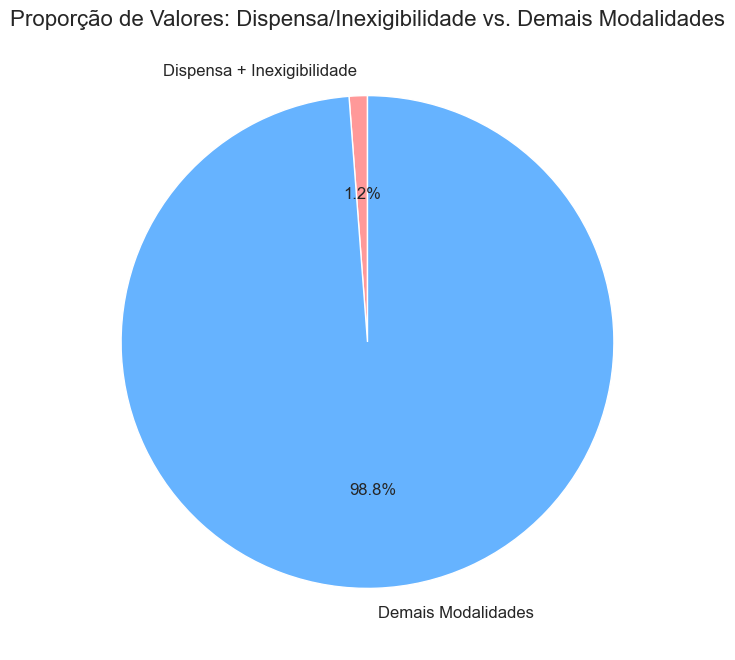

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define um estilo mais bonito para os gráficos
sns.set_style("whitegrid")

# Dados para o gráfico (JÁ ATUALIZADOS com base na sua imagem)
labels = ['Dispensa + Inexigibilidade', 'Demais Modalidades']
valores = [26467505.92, 2187275275.28] # <-- Valores atualizados aqui

# Cria a figura e os eixos
fig, ax = plt.subplots(figsize=(8, 8))

# Gráfico de Pizza
ax.pie(valores, labels=labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
       colors=['#ff9999','#66b3ff']) # Adicionei cores para diferenciar
ax.set_title('Proporção de Valores: Dispensa/Inexigibilidade vs. Demais Modalidades', fontsize=16)
plt.ylabel('')

# Exibe o gráfico
plt.show()

## Analise:
O gráfico evidencia a grande desproporção entre a frequência e o valor das contratações diretas. Embora somem 535 processos, as modalidades de Dispensa e Inexigibilidade representam apenas 1.2% do valor total, indicando que a maior parte dos recursos (98.8%) é alocada via modalidades competitivas, como o Pregão.

## Histogramas:

Nesta seção, serão geradas diferentes visualizações para explorar a distribuição da variável Valor Licitação. Primeiramente, será feita a criação de dois histogramas em escala logarítmica para analisar a frequência dos valores, dividindo os dados em um para as modalidades competitivas e outro para as modalidades de dispensa e inexigibilidade. Em seguida, para comparar as duas distribuições de forma direta, será gerado um Gráfico de Densidade (KDE Plot), que sobrepõe as curvas de frequência dos dois grupos em um único eixo.

Histograma para modalidades competitivas agrupadas (a partir de df_limpo)

Total de licitações competitivas analisadas: 1092


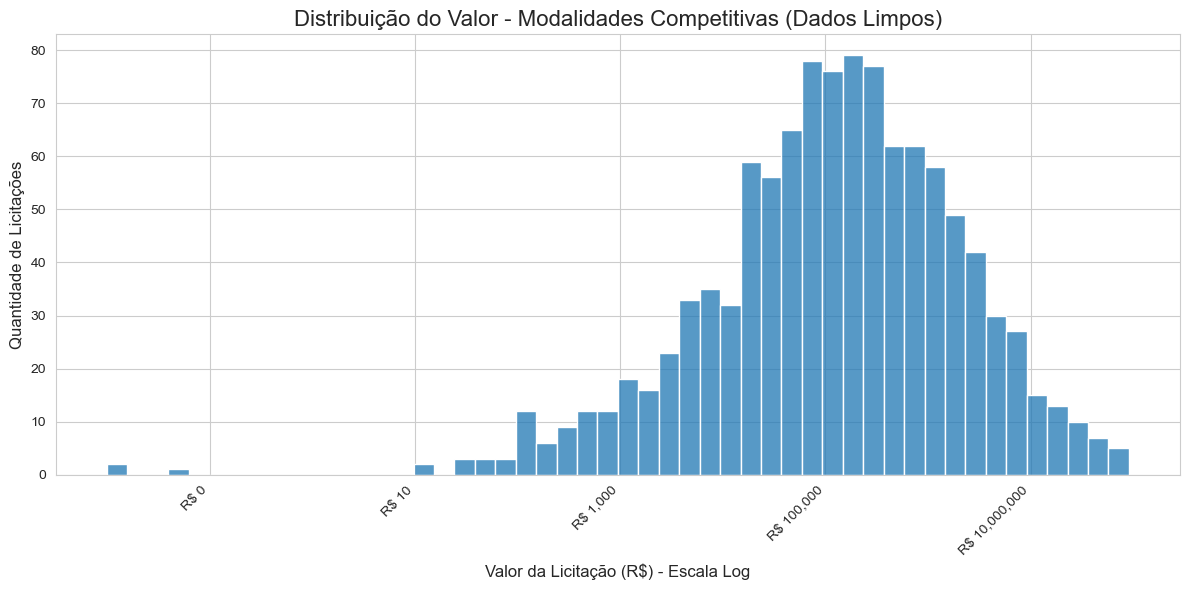

In [23]:
# 1. A lista de modalidades permanece a mesma
modalidades_competitivas = [
    'Pregão',
    'Pregão - Registro de Preço',
    'Concorrência',
    'Tomada de Preços'
]

# 2. Filtra o DataFrame 'df_limpo' para incluir apenas essas modalidades
# A única mudança é usar 'df_limpo' em vez de 'df'
df_competitivas_limpo = df_limpo[
    (df_limpo['Modalidade Compra'].isin(modalidades_competitivas)) & 
    (df_limpo['Valor Licitação'] > 0)
].copy()

# 3. Configura e gera o gráfico
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.histplot(
    data=df_competitivas_limpo, # Usando o novo DataFrame filtrado
    x='Valor Licitação',
    bins=50,
    log_scale=True
)

# 4. Ajusta os rótulos e o título
ax.set_title('Distribuição do Valor - Modalidades Competitivas (Dados Limpos)', fontsize=16)
ax.set_xlabel('Valor da Licitação (R$) - Escala Log', fontsize=12)
ax.set_ylabel('Quantidade de Licitações', fontsize=12)
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))
plt.xticks(rotation=45, ha='right')

# 5. Finalizar e exibir
plt.tight_layout()
#plt.savefig('histograma_competitivas_agrupadas.png')
 
print("Histograma para modalidades competitivas agrupadas (a partir de df_limpo)")
print(f"\nTotal de licitações competitivas analisadas: {len(df_competitivas_limpo)}")

Histograma para dispensas de licitações agrupadas

Total de licitações por dispensa/inexigibilidade analisadas: 531


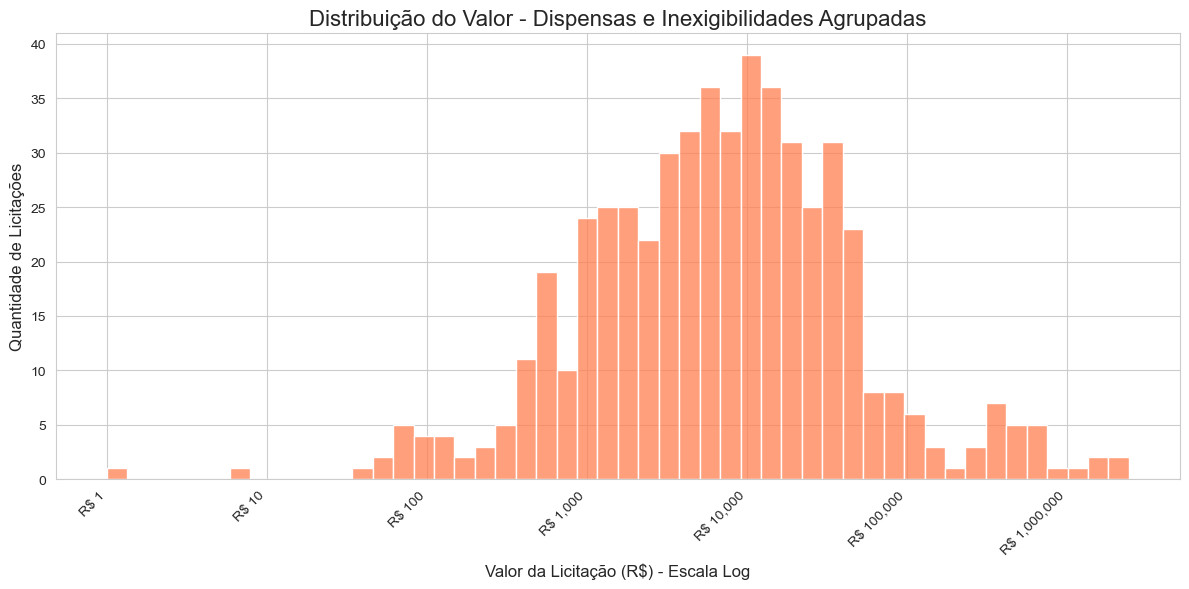

In [24]:
    # 1. Define a lista de modalidades sem competição
    modalidades_dispensa = [
        'Dispensa de Licitação',
        'Inexigibilidade de Licitação'
    ]

    # 2. Filtra o DataFrame para incluir apenas essas modalidades
    df_dispensas = df[
        (df['Modalidade Compra'].isin(modalidades_dispensa)) & 
        (df['Valor Licitação'] > 0)
    ].copy()

    # 3. Configura e gera o gráfico
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    ax = sns.histplot(
        data=df_dispensas,
        x='Valor Licitação',
        bins=50,
        log_scale=True,
        color='coral' # Usando uma cor diferente para diferenciar
    )

    # 4. Ajusta os rótulos e o título
    ax.set_title('Distribuição do Valor - Dispensas e Inexigibilidades Agrupadas', fontsize=16)
    ax.set_xlabel('Valor da Licitação (R$) - Escala Log', fontsize=12)
    ax.set_ylabel('Quantidade de Licitações', fontsize=12)
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))
    plt.xticks(rotation=45, ha='right')

    # 5. Finalizar e salvar
    plt.tight_layout()
    #plt.savefig('histograma_dispensas_agrupadas.png')
    
    print("Histograma para dispensas de licitações agrupadas")
    print(f"\nTotal de licitações por dispensa/inexigibilidade analisadas: {len(df_dispensas)}")



# Analise:
A análise revela que o mercado de compras públicas opera em duas faixas de valor distintas: as licitações competitivas são utilizadas para contratos de alto valor, com um pico de oportunidades em torno de R 100.000, enquanto as dispensas de licitação se aplicam a compras ágeis e de baixo valor, com uma concentração dez vezes menor, na faixa de R 10.000. Essa divisão clara é um reflexo direto dos limites impostos pela lei, o que cria dois mercados distintos com estratégias e oportunidades diferentes para os fornecedores.

# KDE Plot:

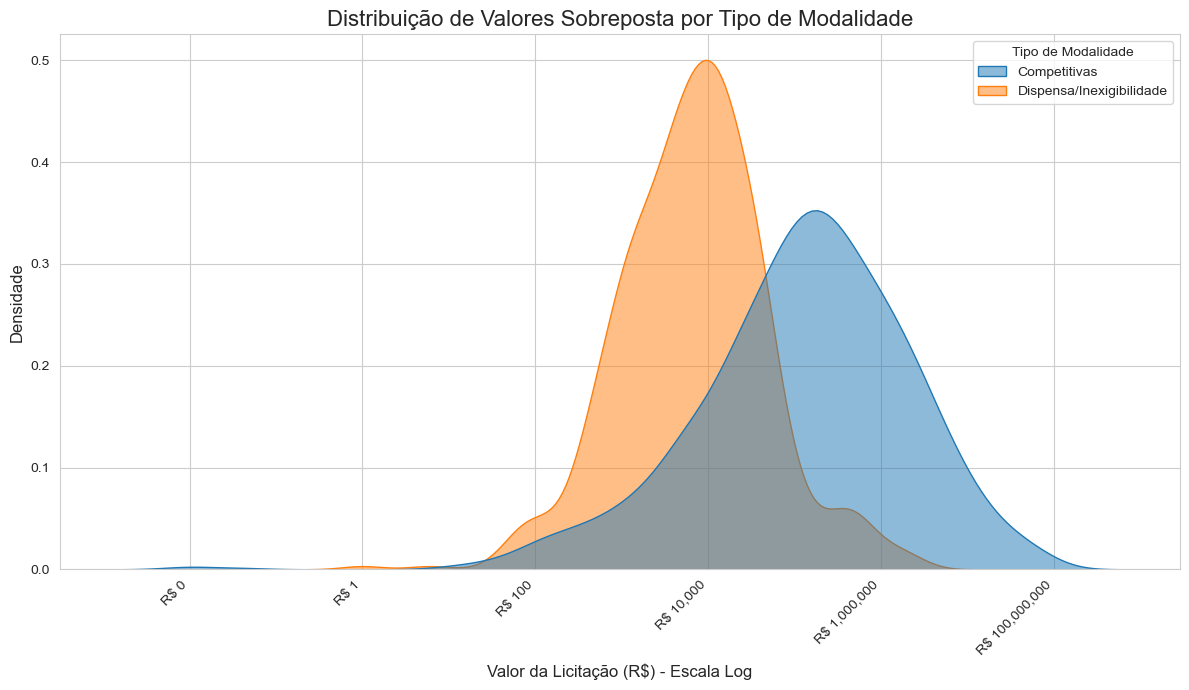

In [34]:

# Lista de modalidades para cada grupo
modalidades_competitivas = [
    'Pregão', 'Pregão - Registro de Preço', 'Concorrência', 'Tomada de Preços'
]
modalidades_dispensa = [
    'Dispensa de Licitação', 'Inexibilidade de Licitação'
]

# Filtra o DataFrame original (df) para valores maiores que zero
df_plot = df[df['Valor Licitação'] > 0].copy()

# Cria a nova coluna 'Tipo de Modalidade' para categorizar os dados
df_plot['Tipo de Modalidade'] = np.where(
    df_plot['Modalidade Compra'].isin(modalidades_competitivas),
    'Competitivas',
    'Dispensa/Inexigibilidade'
)

# Filtra para manter apenas os dois grupos de interesse
df_plot = df_plot[df_plot['Tipo de Modalidade'].isin(['Competitivas', 'Dispensa/Inexigibilidade'])]


# --- ETAPA 2: Gerar o gráfico KDE ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.kdeplot(
    data=df_plot,
    x='Valor Licitação',
    hue='Tipo de Modalidade', # Cria uma curva para cada categoria
    log_scale=True,
    fill=True,              # Preenche a área sob a curva
    common_norm=False,      # Normaliza cada curva independentemente
    alpha=0.5               # Deixa as curvas semitransparentes
)

# --- ETAPA 3: Ajustar os rótulos e o título ---
ax.set_title('Distribuição de Valores Sobreposta por Tipo de Modalidade', fontsize=16)
ax.set_xlabel('Valor da Licitação (R$) - Escala Log', fontsize=12)
ax.set_ylabel('Densidade', fontsize=12)

# Formata o eixo X para exibir como moeda (R$) - LINHA CORRIGIDA
formatter = mticker.FuncFormatter(lambda x, p: f'R$ {x:,.0f}')
ax.get_xaxis().set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right')

# --- ETAPA 4: Finalizar e exibir o gráfico ---
plt.tight_layout()
plt.show()

# Analise:
As modalidades competitivas (em azul) concentram-se em valores significativamente mais altos, com seu pico de frequência em torno de R 100.000, sendo o mecanismo para contratos de maior vulto. Em nítido contraste, as contratações por dispensa ou inexigibilidade (em laranja) possuem seu pico em uma ordem de magnitude inferior, ao redor de R 10.000, evidenciando seu uso para aquisições menores e mais ágeis.

# Boxplots

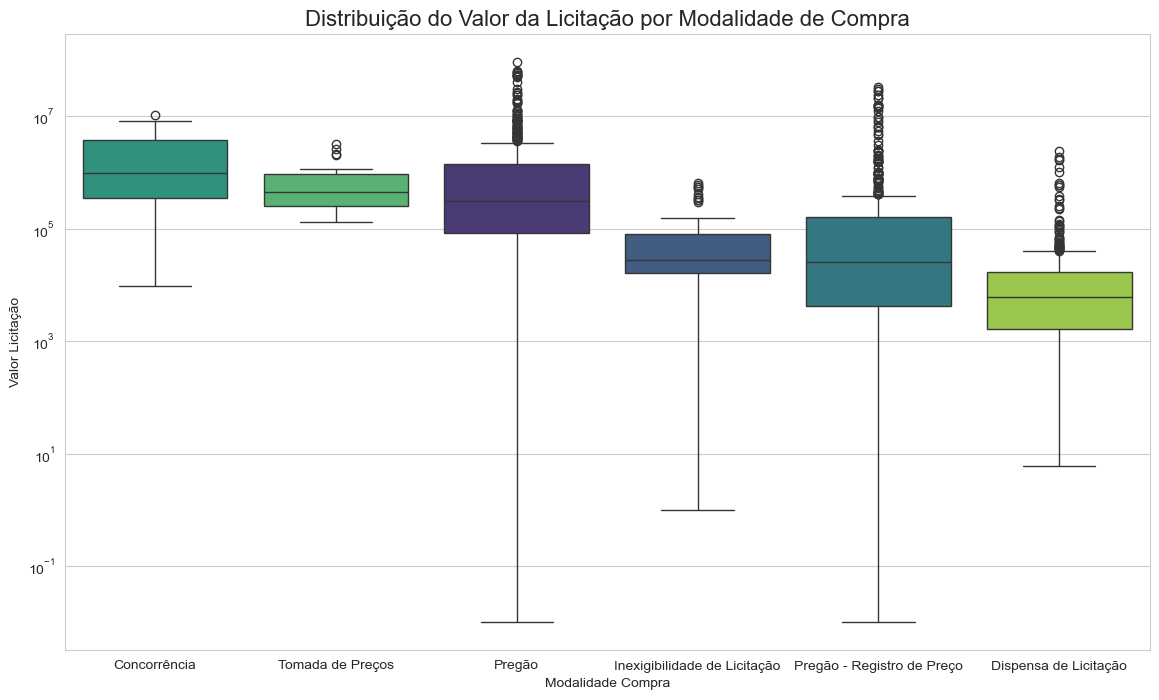

In [31]:

# Filtra os dados (note que não estamos carregando nem limpando mais)
df_plot = df[df['Valor Licitação'] > 0].copy()

# Ordena as categorias
median_order = df_plot.groupby('Modalidade Compra')['Valor Licitação'].median().sort_values(ascending=False).index

# Gera o gráfico
plt.figure(figsize=(14, 8))
ax = sns.boxplot(x='Modalidade Compra', y='Valor Licitação', data=df_plot, order=median_order, hue='Modalidade Compra', palette="viridis", legend=False)
ax.set_yscale('log')
ax.set_title('Distribuição do Valor da Licitação por Modalidade de Compra', fontsize=16)
# ... (resto da formatação do gráfico)
plt.show()

# Analise:

O boxplot confirma visualmente a separação entre dois mercados de compras públicas: um de alto valor, operado por modalidades competitivas como Pregão e Concorrência, e outro de baixo valor, atendido por contratações diretas. A presença de outliers significativos, principalmente em dispensas, pode ser um ponto de atenção para análises futuras, a fim de investigar se contratos de valor atipicamente alto estão sendo executados sem a devida competição.

# Gráfico de disperção:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Número Licitação          2537 non-null   int64         
 1   Código UG                 2537 non-null   int64         
 2   Nome UG                   2537 non-null   object        
 3   Código Modalidade Compra  2537 non-null   int64         
 4   Modalidade Compra         2537 non-null   object        
 5   Número Processo           2537 non-null   object        
 6   Objeto                    2537 non-null   object        
 7   Situação Licitação        2537 non-null   object        
 8   Código Órgão Superior     2537 non-null   int64         
 9   Nome Órgão Superior       2537 non-null   object        
 10  Código Órgão              2537 non-null   int64         
 11  Nome Órgão                2537 non-null   object        
 12  UF                  

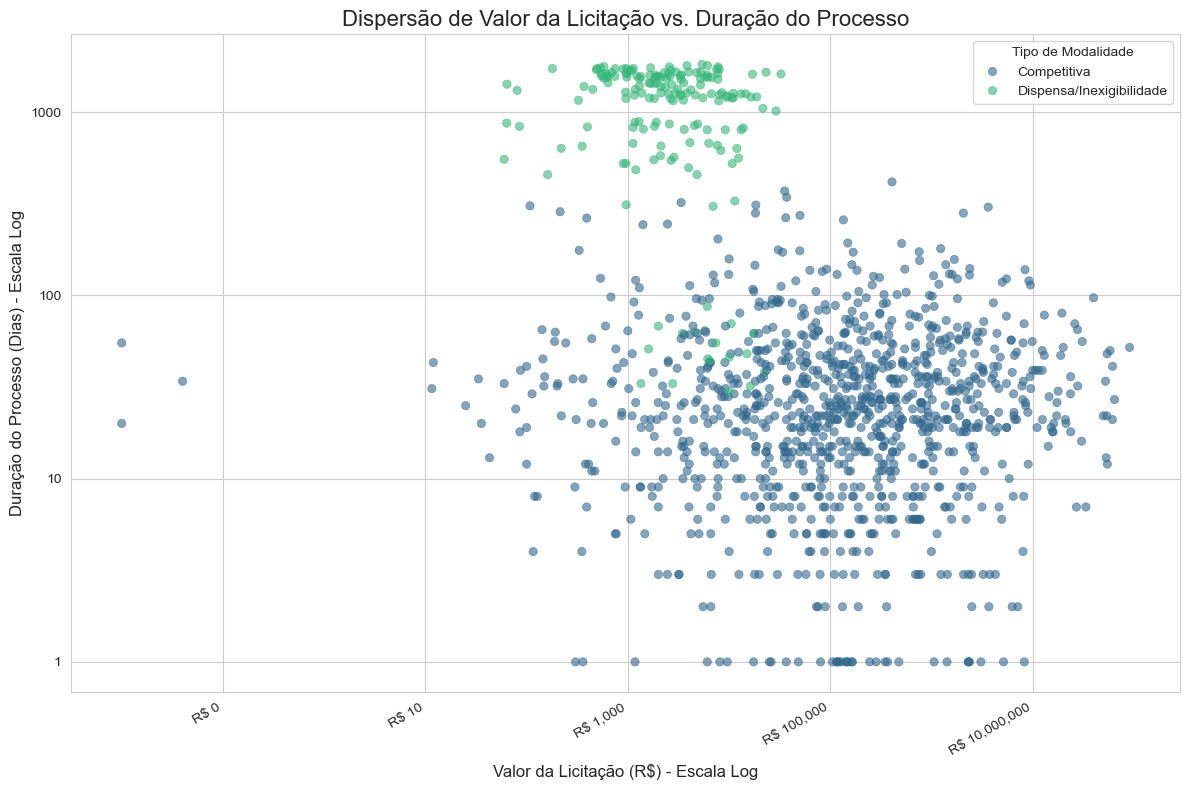

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- ETAPA 1: Carregar e Limpar os Dados ---
try:
    df.info()
except NameError:
    print("DataFrame 'df' não encontrado. Carregando e limpando os dados...")
    df = pd.read_csv("202401_Licitacao.csv", encoding='latin-1', sep=';')
    df['Valor Licitação'] = df['Valor Licitação'].astype(str).str.replace(',', '.', regex=False)
    df['Valor Licitação'] = pd.to_numeric(df['Valor Licitação'], errors='coerce')
    df['Data Resultado Compra'] = pd.to_datetime(df['Data Resultado Compra'], dayfirst=True, errors='coerce')
    df['Data Abertura'] = pd.to_datetime(df['Data Abertura'], dayfirst=True, errors='coerce')
    df.dropna(subset=['Valor Licitação', 'Data Resultado Compra', 'Data Abertura'], inplace=True)

# --- ETAPA 2: Calcular a Duração e Criar o DataFrame Limpo ---
df['Duracao_dias'] = (df['Data Resultado Compra'] - df['Data Abertura']).dt.days

# Remove durações negativas ou nulas e valores de licitação iguais a zero
df_limpo = df[(df['Duracao_dias'] >= 0) & (df['Valor Licitação'] > 0)].copy()

# --- ETAPA 3: Criar a Categoria para a Cor (Hue) ---
modalidades_competitivas = [
    'Pregão', 'Pregão - Registro de Preço', 'Concorrência', 'Tomada de Preços'
]
df_limpo['Tipo de Modalidade'] = df_limpo['Modalidade Compra'].apply(
    lambda x: 'Competitiva' if x in modalidades_competitivas else 'Dispensa/Inexigibilidade'
)

# --- ETAPA 4: Gerar o Gráfico de Dispersão ---
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

ax = sns.scatterplot(
    data=df_limpo,
    x='Valor Licitação',
    y='Duracao_dias',
    hue='Tipo de Modalidade',
    palette='viridis',
    alpha=0.6,
    edgecolor=None
)

# --- ETAPA 5: Formatação e Títulos ---
ax.set_title('Dispersão de Valor da Licitação vs. Duração do Processo', fontsize=16)
ax.set_xlabel('Valor da Licitação (R$) - Escala Log', fontsize=12)
ax.set_ylabel('Duração do Processo (Dias) - Escala Log', fontsize=12)

# Usar escala logarítmica para ambos os eixos para lidar com a grande variação de valores
ax.set_xscale('log')
ax.set_yscale('log')

# Formata os eixos para melhor leitura
formatter_x = mticker.FuncFormatter(lambda x, p: f'R$ {x:,.0f}')
ax.get_xaxis().set_major_formatter(formatter_x)
ax.get_yaxis().set_major_formatter(mticker.ScalarFormatter())

plt.xticks(rotation=30, ha='right')
plt.legend(title='Tipo de Modalidade')
plt.tight_layout()
plt.show()

# Analise:
A visualização da dispersão entre o valor da licitação e a duração do processo revelou anomalias significativas que merecem investigação. Dois extremos se destacam: primeiro, um agrupamento de processos, surpreendentemente da modalidade "Dispensa/Inexigibilidade", com duração superior a 1000 dias, o que contradiz a natureza ágil esperada para este tipo de contratação. No outro extremo, foi identificada uma quantidade expressiva de licitações "Competitivas" concluídas em apenas 1 dia, um prazo notavelmente curto para um processo que exige concorrência. Esses outliers são fortes indicativos de possíveis erros de registro de dados, ineficiências burocráticas ou processos que fogem ao padrão e necessitam de uma análise mais específica. Fora desses extremos, a nuvem de pontos principal não sugere uma correlação direta e forte entre o aumento do valor e a duração da licitação.

## 4. Discussão Preliminar
A análise exploratória dos dados de licitações de janeiro de 2024 revelou padrões claros e, ao mesmo tempo, levantou importantes questões sobre a qualidade dos dados. O principal padrão observado foi a forte relação entre a modalidade de compra e o valor da licitação. Ficou evidente que as contratações públicas operam em dois clusters de valores distintos: as modalidades competitivas, como o Pregão, são consistentemente utilizadas para contratos de valor elevado (com pico de frequência em torno de RS 100.000), enquanto as dispensas e inexigibilidades de licitação se concentram em aquisições de baixo valor (pico em torno de RS 10.000). Por outro lado, não foi observada uma correlação direta e forte entre o valor e a duração do processo, exceto pela identificação de anomalias.

Contudo, a análise foi marcada por significativas questões de qualidade dos dados que impactaram diretamente os resultados. Inicialmente, a variável Data Abertura apresentou 411 valores ausentes (cerca de 16%), e foi necessária a padronização de variáveis como Valor Licitação e as próprias datas. Mais preocupantes foram os dados inconsistentes identificados: foi encontrado um registro com duração de processo negativa (-315 dias), um claro erro de lançamento. O gráfico de dispersão também expôs anomalias contraintuitivas, como processos de dispensa de licitação com duração superior a 1000 dias e licitações competitivas concluídas em apenas 1 dia. Adicionalmente, o gráfico de boxplot reforçou a presença de outliers, destacando a existência de contratações por dispensa de licitação com valores atipicamente elevados, o que foge ao padrão esperado para essa modalidade e pode ser um ponto de atenção para análises futuras.

Esses problemas têm implicações diretas para a modelagem futura. Os outliers e dados inconsistentes, tanto nos valores quanto na duração, representam um risco, pois podem distorcer severamente qualquer modelo preditivo. Portanto, o tratamento dessas anomalias será uma etapa crucial no pré-processamento. A clara segmentação de valores por tipo de modalidade também sugere que a criação de modelos separados para contratações competitivas e diretas pode gerar resultados mais precisos.

## 5. Próximos Passos
Como próximos passos, será necessário realizar o tratamento dos problemas de qualidade dos dados identificados na análise exploratória. Isso incluirá a remoção dos registros com valores ausentes na Data Abertura, bem como o tratamento dos dados inconsistentes e outliers, como o processo de duração negativa e as anomalias de prazo e valor observadas nos gráficos, a fim de não distorcer a futura modelagem.

A variável-alvo definida para a modelagem será a Modalidade Compra, que será transformada em uma variável binária para classificar se a contratação foi "Direta" (agrupando Dispensa e Inexigibilidade) ou "Competitiva". Como variáveis preditoras iniciais, serão utilizadas Valor Licitação, Nome Órgão Superior e UF, com o objetivo de investigar os principais fatores que influenciam a escolha por uma dispensa de licitação.

Pretende-se testar inicialmente modelos de classificação como a Regressão Logística e Árvores de Decisão. A Regressão Logística servirá para estabelecer um baseline de performance, enquanto a Árvore de Decisão permitirá uma análise mais interpretável das regras (como limiares de valor) que levam à utilização da dispensa, contribuindo diretamente para responder ao problema de pesquisa sobre a habitualidade dessa prática.

## Referências 
- Controladoria-Geral da União (CGU). Licitações do Poder Executivo Federal - Janeiro/2024. Disponível em: https://portaldatransparencia.gov.br/download-de-dados/licitacoes.

 

---